# Perceptron

## Iris dataset

Task: Classify two iris species using two features: petal length and petal width.

Classes: Iris setosa (+1) vs. Iris versicolor (−1).

These two are linearly separable with these features, so the perceptron must converge.

### Load libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris  
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler




### Load data

In [3]:
iris = load_iris()
X_all = iris['data'][:, 2:4]  # petal length, petal width
y_all = iris['target']        # 0=setosa, 1=versicolor, 2=virginica

mask = (y_all == 0) | (y_all == 1)       # keep setosa & versicolor
X = X_all[mask].astype(float)
y = y_all[mask]
y = np.where(y == 0, +1, -1)             # +1 for setosa, -1 for versicolor


### Visualize data

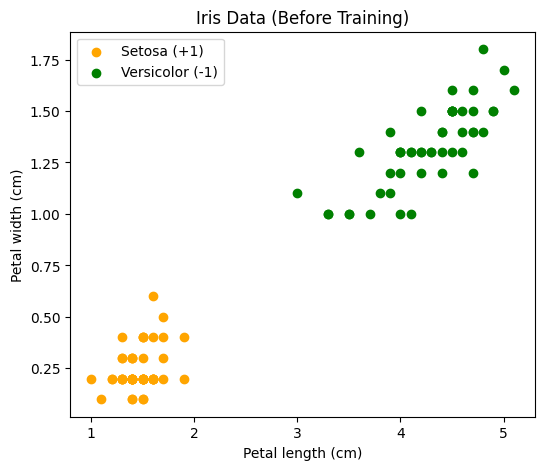

In [4]:
plt.figure(figsize=(6, 5))
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="orange", label="Setosa (+1)")
plt.scatter(X[y == -1, 0], X[y == -1, 1], color="green", label="Versicolor (-1)")
plt.title("Iris Data (Before Training)")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend()
plt.show()

### Partition data (stratified sampling)

In [5]:
# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### Scale data

In [6]:
# use standardization method

# Define scaler
scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply scaler on test data
X_test_scaled = scaler.transform(X_test)


### Call model

In [7]:
clf_model = Perceptron(fit_intercept=True, shuffle=True, max_iter=50)


### Train model

In [8]:
clf_model.fit(X_train_scaled, y_train)


,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,50
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


### Access model parameters

In [9]:
w1, w2 = clf_model.coef_[0]
b = clf_model.intercept_[0]
print("Weights (w1, w2):", (w1, w2))
print("Bias (b):", b)
print("Number of passes (n_iter_):", clf_model.n_iter_)

Weights (w1, w2): (np.float64(-1.5244655721500373), np.float64(-1.4244430555772531))
Bias (b): 0.0
Number of passes (n_iter_): 6


### Generate predictions

In [10]:
# predictions on train and test sets

y_pred_train = clf_model.predict(X_train_scaled)
y_pred_test = clf_model.predict(X_test_scaled)



### Evaluate model performance

In [11]:
# evaluation on train and test sets using accuracy metric

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Training accuracy: {acc_train:.3f}")
print(f"Testing accuracy: {acc_test:.3f}")


Training accuracy: 1.000
Testing accuracy: 1.000


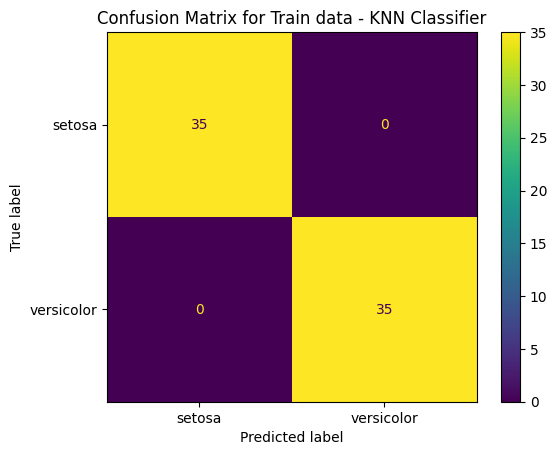

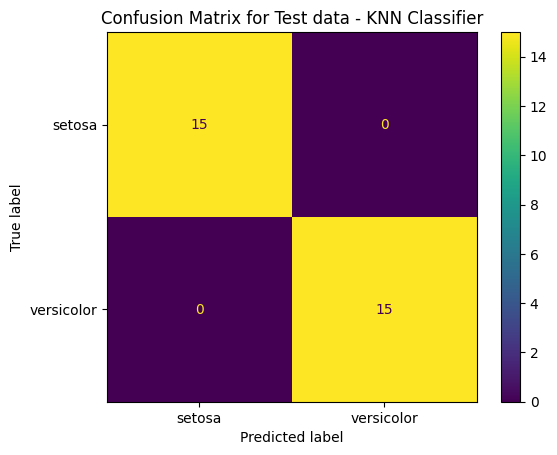

In [18]:
# visualize the confusion metric and interpret the results

# compute the confusion matrix
train_cm = confusion_matrix(y_train, y_pred_train)
test_cm = confusion_matrix(y_test, y_pred_test)

# 8.1. Plot confusion matrix for train data
disp = ConfusionMatrixDisplay(confusion_matrix=train_cm, display_labels=iris.target_names[:2])
disp.plot(cmap='viridis', values_format='d')
plt.title("Confusion Matrix for Train data - KNN Classifier")
plt.show()

# 8.2. Plot confusion matrix for test data
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=iris.target_names[:2])
disp.plot(cmap='viridis', values_format='d')
plt.title("Confusion Matrix for Test data - KNN Classifier")
plt.show()


### Plot decision boundary


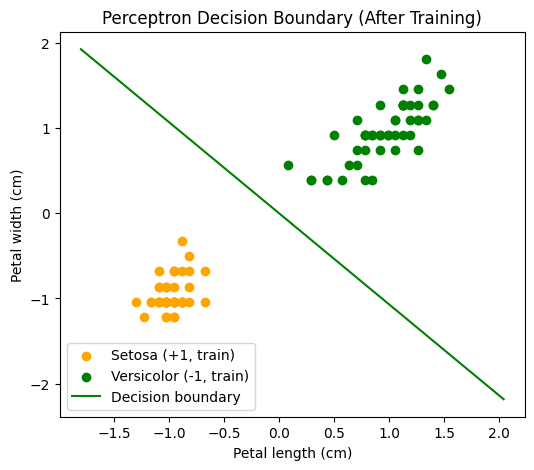

In [ ]:
plt.figure(figsize=(6, 5))
# Plot train points
plt.scatter(X_train_scaled[y_train==+1,0], X_train_scaled[y_train==+1,1],
            label="Setosa (+1, train)", color="orange", marker="o")
plt.scatter(X_train_scaled[y_train==-1,0], X_train_scaled[y_train==-1,1],
            label="Versicolor (-1, train)", color="green", marker="o")
# Plot test points
plt.scatter(X_test_scaled[y_test==+1,0], X_test_scaled[y_test==+1,1], color="orange", marker="o")
plt.scatter(X_test_scaled[y_test==-1,0], X_test_scaled[y_test==-1,1], color="green", marker="o")

# Plot the classifier line 
# Equation: w1*x1 + w2*x2 + b = 0  →  x2 = -(w1/w2)*x1 - b/w2
x1 = np.linspace(X_train_scaled[:,0].min()-0.5, X_train_scaled[:,0].max()+0.5, 200)
x2 = -(w1/w2) * x1 - b / w2

plt.plot(x1, x2, color="green", label="Decision boundary")
plt.title("Perceptron Decision Boundary (After Training)")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend()
plt.show()

## Breast Cancer dataset

In [ ]:
# Load dataset
from sklearn.datasets import load_breast_cancer


data = load_breast_cancer()
X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Target labels:", np.unique(y), data.target_names)